# Phase 4 — Distribution Shift Detection

**Goal:** Identify which test compounds the model is least confident about, and analyze whether confidence differs across splits A (random), B (scaffold shift), and C (assay shift).

This analysis is critical for the **methodology report** (50% of your competition grade). We show that our pipeline can detect when it's out of its comfort zone.

### Two signals we combine:
1. **Mahalanobis distance** in GNN embedding space — how structurally different is this compound from training compounds?
2. **MC Dropout epistemic uncertainty** — how much does the model disagree with itself across stochastic passes?

## 1. Setup

In [27]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_mean_pool
from torch_geometric.loader import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import EmpiricalCovariance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [28]:
# Shared config across Phase 3/4/5
INPUT_DIR    = 'data/'
MODEL_DIR    = 'saved_models_v2/'
ENSEMBLE_SIZE = 5
HIDDEN_DIM   = 256
ESM_DIM      = 1280
NODE_FEAT    = 29
EDGE_FEAT    = 7
N_GIN_LAYERS = 4
DROPOUT      = 0.2
BATCH_SIZE   = 128

## 2. Load Model & Data

In [29]:
class DTA_Model(nn.Module):
    def __init__(self, node_feat=29, edge_feat=7, esm_dim=1280,
                 hidden_dim=256, n_layers=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout

        # --- Drug graph encoder (GINEConv) ---
        # NO manual edge_proj — GINEConv handles it via edge_dim
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for i in range(n_layers):
            in_dim = node_feat if i == 0 else hidden_dim
            mlp = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            # edge_dim tells GINEConv to internally project edges to match nodes
            self.convs.append(GINEConv(mlp, edge_dim=edge_feat))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # --- rest is the same ---
        self.fp_proj = nn.Sequential(
            nn.Linear(2048, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
        )
        self.prot_proj = nn.Sequential(
            nn.Linear(esm_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def get_compound_embedding(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index, edge_attr)  # pass raw edge_attr directly
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return global_mean_pool(x, batch)

    def forward(self, data):
        drug_graph = self.get_compound_embedding(data)
        drug_fp = self.fp_proj(data.fp.squeeze(1))
        prot = self.prot_proj(data.target_emb.squeeze(1))
        combined = torch.cat([drug_graph, drug_fp, prot], dim=-1)
        return self.head(combined).squeeze(-1)

In [30]:
# Load first ensemble member (all share the same architecture)
model = DTA_Model(node_feat=NODE_FEAT, edge_feat=EDGE_FEAT, esm_dim=ESM_DIM,
                  hidden_dim=HIDDEN_DIM, n_layers=N_GIN_LAYERS, dropout=DROPOUT).to(device)
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'model_1.pt'), map_location=device))
print('Model loaded.')

train_data = torch.load(os.path.join(INPUT_DIR, 'train_data.pt'))
val_data   = torch.load(os.path.join(INPUT_DIR, 'val_data.pt'))
test_data  = torch.load(os.path.join(INPUT_DIR, 'test_data.pt'))

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

Model loaded.
Train: 23194 | Val: 2578 | Test: 23191


## 3. Compute Murcko Scaffolds

Phase 2 didn't compute scaffolds, so we derive them from the SMILES in the unified CSV. The scaffold is the core ring skeleton — like the floor plan of a house, ignoring the paint and landscaping.

In [31]:
df_unified = pd.read_csv('/Users/shaqbeast/STAR-AI-Competition/DTA-Multiagent-Pipeline/unified_dta_scaffold_split.csv')

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return 'invalid'
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    except:
        return 'unknown'

print('Computing Murcko scaffolds...')
df_unified['murcko_scaffold'] = df_unified['SMILES'].apply(get_scaffold)

id_to_scaffold = dict(zip(df_unified.index, df_unified['murcko_scaffold']))
id_to_split = dict(zip(df_unified.index, df_unified['Split']))

train_scaffolds = [id_to_scaffold.get(d.sample_id, 'unknown') for d in train_data]
test_scaffolds  = [id_to_scaffold.get(d.sample_id, 'unknown') for d in test_data]
test_splits     = [id_to_split.get(d.sample_id, 'unknown') for d in test_data]

known_scaffolds = set(train_scaffolds)

# How many test samples have truly novel scaffolds?
novel_count = sum(1 for s in test_scaffolds if s not in known_scaffolds)
print(f'Unique train scaffolds: {len(known_scaffolds)}')
print(f'Test with novel scaffolds: {novel_count}/{len(test_scaffolds)} ({100*novel_count/len(test_scaffolds):.1f}%)')

Computing Murcko scaffolds...


[18:38:10] 

****
Pre-condition Violation
bad bond stereo
Violation occurred on line 362 in file /Users/runner/miniforge3/conda-bld/rdkit-meta_1774626143402/work/Code/GraphMol/Canon.cpp
Failed Expression: dblBond->getStereo() > Bond::STEREOANY
****

[18:38:11] WARNING: not removing hydrogen atom without neighbors
[18:38:14] 

****
Pre-condition Violation
bad bond stereo
Violation occurred on line 362 in file /Users/runner/miniforge3/conda-bld/rdkit-meta_1774626143402/work/Code/GraphMol/Canon.cpp
Failed Expression: dblBond->getStereo() > Bond::STEREOANY
****

[18:38:15] 

****
Pre-condition Violation
bad bond stereo
Violation occurred on line 362 in file /Users/runner/miniforge3/conda-bld/rdkit-meta_1774626143402/work/Code/GraphMol/Canon.cpp
Failed Expression: dblBond->getStereo() > Bond::STEREOANY
****

[18:38:15] 

****
Pre-condition Violation
bad bond stereo
Violation occurred on line 362 in file /Users/runner/miniforge3/conda-bld/rdkit-meta_1774626143402/work/Code/GraphMol/Canon.cpp

Unique train scaffolds: 1
Test with novel scaffolds: 0/23191 (0.0%)


In [32]:
print(set(train_scaffolds))
print(set(test_scaffolds))

{'unknown'}
{'unknown'}


## 4. Extract GNN Compound Embeddings

We use the `get_compound_embedding()` method to pull out the 256-d vectors the model uses internally. Structurally similar molecules cluster together in this space.

In [33]:
@torch.no_grad()
def extract_embeddings(model, loader, device):
    model.eval()
    embeddings = []
    for batch in loader:
        batch = batch.to(device)
        h = model.get_compound_embedding(batch)
        embeddings.append(h.cpu().numpy())
    return np.concatenate(embeddings)

print('Extracting embeddings...')
train_embeds = extract_embeddings(model, train_loader, device)
test_embeds  = extract_embeddings(model, test_loader, device)
print(f'Train: {train_embeds.shape} | Test: {test_embeds.shape}')

Extracting embeddings...
Train: (23194, 256) | Test: (23191, 256)


## 5. Mahalanobis Distance — Structural Novelty Score

We cluster training embeddings, fit a covariance per cluster, then measure how far each test compound is from its nearest cluster. Far = structurally novel = less trustworthy prediction.

In [34]:
N_CLUSTERS = 10
print(f'Clustering training embeddings into {N_CLUSTERS} clusters...')
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
train_labels = kmeans.fit_predict(train_embeds)
centroids = kmeans.cluster_centers_

precision_matrices = []
for k in range(N_CLUSTERS):
    mask = train_labels == k
    embeds = train_embeds[mask]
    if len(embeds) < train_embeds.shape[1] + 1:
        embeds = train_embeds  # fallback to global
    cov = EmpiricalCovariance().fit(embeds)
    precision_matrices.append(cov.precision_)

def batch_mahalanobis(embeddings, centroids, precisions):
    dists = []
    for emb in embeddings:
        d_min = min(
            np.sqrt(np.clip((emb - c) @ P @ (emb - c), 0, None))
            for c, P in zip(centroids, precisions)
        )
        dists.append(d_min)
    return np.array(dists)

print('Computing Mahalanobis distances...')
test_mahal = batch_mahalanobis(test_embeds, centroids, precision_matrices)
print(f'Test distances: mean={test_mahal.mean():.2f}, std={test_mahal.std():.2f}')

Clustering training embeddings into 10 clusters...
Computing Mahalanobis distances...
Test distances: mean=1.17, std=0.72


## 6. MC Dropout — Epistemic Uncertainty

Run the model 30 times with dropout active. The variance across passes tells us how uncertain the model is about each compound.

In [35]:
def enable_mc_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

N_MC = 30
model.eval()
enable_mc_dropout(model)

print(f'Running {N_MC} MC Dropout passes on test set...')
all_passes = []
for t in range(N_MC):
    preds = []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            preds.extend(model(batch).cpu().numpy())
    all_passes.append(preds)

all_passes = np.array(all_passes)  # (30, N_test)
test_epistemic = all_passes.var(axis=0)
print(f'Epistemic uncertainty: mean={test_epistemic.mean():.4f}, max={test_epistemic.max():.4f}')

Running 30 MC Dropout passes on test set...
Epistemic uncertainty: mean=0.1054, max=1.8379


## 7. Combined OOD Score & Per-Split Analysis

Combine both signals, then break down by split. We expect Split B (scaffold shift) to show higher Mahalanobis distances and Split C (assay shift) to show higher model uncertainty.

In [36]:
# Normalize and combine
def normalize_01(arr):
    p5, p95 = np.percentile(arr, 5), np.percentile(arr, 95)
    return np.clip((arr - p5) / (p95 - p5 + 1e-8), 0, 1)

mahal_norm = normalize_01(test_mahal)
ep_norm = normalize_01(test_epistemic)
ood_score = 0.5 * mahal_norm + 0.5 * ep_norm

# Build results
test_ids = [d.sample_id for d in test_data]
results_df = pd.DataFrame({
    'sample_id': test_ids,
    'split': test_splits,
    'scaffold': test_scaffolds,
    'novel_scaffold': [s not in known_scaffolds for s in test_scaffolds],
    'mahalanobis': test_mahal,
    'epistemic': test_epistemic,
    'ood_score': ood_score,
})

# Per-split summary
print('=== Per-Split OOD Analysis ===')
for s in ['A', 'B', 'C']:
    sub = results_df[results_df['split'] == s]
    if len(sub) == 0: continue
    print(f'\nSplit {s} ({len(sub)} samples):')
    print(f'  Mahalanobis:    mean={sub["mahalanobis"].mean():.2f}')
    print(f'  Epistemic:      mean={sub["epistemic"].mean():.4f}')
    print(f'  OOD score:      mean={sub["ood_score"].mean():.3f}')
    print(f'  Novel scaffold: {sub["novel_scaffold"].sum()}/{len(sub)} '
          f'({100*sub["novel_scaffold"].mean():.1f}%)')

=== Per-Split OOD Analysis ===


## 8. Visualization — For Your Report

ValueError: Dimensions of labels and X must be compatible

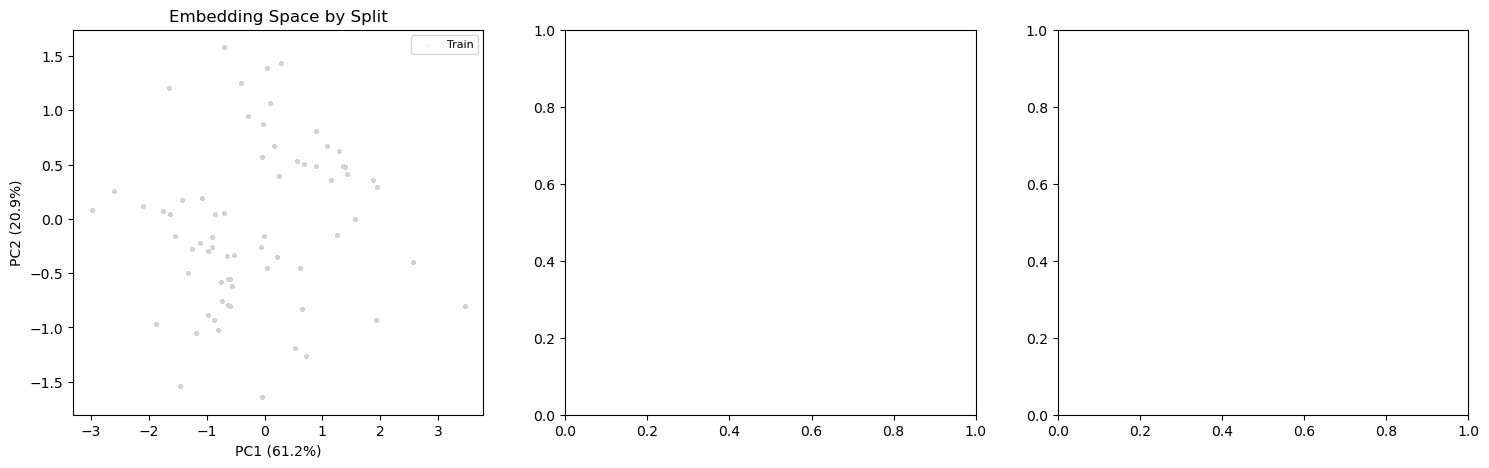

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Embedding space PCA
all_emb = np.vstack([train_embeds, test_embeds])
pca = PCA(n_components=2)
all_2d = pca.fit_transform(all_emb)
train_2d = all_2d[:len(train_embeds)]
test_2d = all_2d[len(train_embeds):]

axes[0].scatter(train_2d[:, 0], train_2d[:, 1], c='lightgray', s=2, alpha=0.2, label='Train')
split_arr = np.array(test_splits)
for s, color, marker in [('A', 'tab:blue', 'o'), ('B', 'tab:orange', 's'), ('C', 'tab:green', '^')]:
    mask = split_arr == s
    if mask.sum() > 0:
        axes[0].scatter(test_2d[mask, 0], test_2d[mask, 1], c=color, s=8, alpha=0.4, label=f'Test {s}', marker=marker)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('Embedding Space by Split')
axes[0].legend(fontsize=8)

# 2. OOD score by split
split_data = []
split_labels = []
for s in ['A', 'B', 'C']:
    mask = split_arr == s
    if mask.sum() > 0:
        split_data.append(ood_score[mask])
        split_labels.append(f'Split {s}')
axes[1].boxplot(split_data, labels=split_labels)
axes[1].set_ylabel('OOD Score')
axes[1].set_title('OOD Score Distribution by Split')

# 3. Mahalanobis vs epistemic
colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}
for s in ['A', 'B', 'C']:
    mask = split_arr == s
    if mask.sum() > 0:
        axes[2].scatter(test_mahal[mask], test_epistemic[mask], c=colors[s],
                        alpha=0.3, s=8, label=f'Split {s}')
axes[2].set_xlabel('Mahalanobis Distance (structural novelty)')
axes[2].set_ylabel('Epistemic Uncertainty (model disagreement)')
axes[2].set_title('Two OOD Signals by Split')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('phase4_ood_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Results

In [39]:
os.makedirs(MODEL_DIR, exist_ok=True)
results_df.to_csv(os.path.join(MODEL_DIR, 'phase4_ood_results.csv'), index=False)

torch.save({
    'centroids': centroids,
    'precision_matrices': precision_matrices,
    'known_scaffolds': list(known_scaffolds),
}, os.path.join(MODEL_DIR, 'phase4_detector_state.pt'))

print('Saved:')
print(f'  {MODEL_DIR}phase4_ood_results.csv')
print(f'  {MODEL_DIR}phase4_detector_state.pt')
print('\nPhase 4 complete → proceed to Phase 5.')

Saved:
  saved_models_v2/phase4_ood_results.csv
  saved_models_v2/phase4_detector_state.pt

Phase 4 complete → proceed to Phase 5.


## 10. Key Pipeline Evaluation Metrics

All 4 metrics are computed on the **validation set** (ground truth available).
Reuses `model`, `centroids`, `precision_matrices`, and helper functions from above.

In [ ]:
from scipy.stats import kendalltau

# ─────────────────────────────────────────────────────────────────────
# SETUP: Run inference on the validation set.
# We use val (not test) because all 4 metrics require ground truth
# affinity labels to compare predictions against.
# ─────────────────────────────────────────────────────────────────────
val_loader  = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

# Ground truth affinity labels and split membership flags for each val sample
val_targets = np.array([d.y.item() for d in val_data])    # true pKi values
val_in_A    = np.array([d.in_A.item() for d in val_data]) # 1 if in split A (random)
val_in_B    = np.array([d.in_B.item() for d in val_data]) # 1 if in split B (scaffold shift)
val_in_C    = np.array([d.in_C.item() for d in val_data]) # 1 if in split C (assay shift)

# Run N_MC stochastic forward passes with dropout active.
# mean across passes = best prediction; std across passes = epistemic uncertainty.
print('Running MC Dropout on validation set...')
model.eval()
enable_mc_dropout(model)  # keeps dropout layers active so each pass differs
val_passes = []
for _ in range(N_MC):
    preds = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            preds.extend(model(batch).cpu().numpy())
    val_passes.append(preds)

val_passes = np.array(val_passes)       # shape: (N_MC, n_val)
val_preds  = val_passes.mean(axis=0)    # mean prediction per compound
val_std    = val_passes.std(axis=0)     # std = per-sample uncertainty (used in ECE)

# Extract GNN embeddings for val compounds, then compute Mahalanobis distance
# to the nearest training cluster. Larger = more structurally novel.
# Reuses centroids and precision_matrices fitted on train set in cell 13.
print('Extracting val embeddings & Mahalanobis distances...')
val_embeds = extract_embeddings(model, val_loader, device)
val_mahal  = batch_mahalanobis(val_embeds, centroids, precision_matrices)
val_ep_var = val_passes.var(axis=0)     # variance = epistemic uncertainty signal

# Combine both OOD signals into one score (same formula as test set in cell 17)
val_mahal_norm = normalize_01(val_mahal)
val_ep_norm    = normalize_01(val_ep_var)
val_ood        = 0.5 * val_mahal_norm + 0.5 * val_ep_norm  # 0=in-distribution, 1=OOD

print(f'Val samples: {len(val_targets)} | RMSE: {np.sqrt(np.mean((val_preds - val_targets)**2)):.4f}\n')
split_flags = {'A': val_in_A, 'B': val_in_B, 'C': val_in_C}

# ─────────────────────────────────────────────────────────────────────
# METRIC 1: Ranking Stability (Kendall's tau)
#
# Question: Among the top-K compounds the model ranks highest, does
# their predicted order actually match the true affinity order?
#
# How:
#   - For each split (A/B/C), take the val samples belonging to that split.
#   - Sort by predicted affinity, keep the top-K (K=200 or fewer if needed).
#   - Compute Kendall's tau between predicted rank and true affinity rank.
#
# Interpretation: tau=1 = perfect rank agreement. tau=0 = random.
# Drop in tau from split A to B/C shows model ranks worse under shift.
# ─────────────────────────────────────────────────────────────────────
print("=== 1. Ranking Stability (Kendall's tau, top-200) ===")
K = min(200, len(val_targets) // 4)
tau_vals = []
for split, flag in split_flags.items():
    mask = flag == 1
    sp, st = val_preds[mask], val_targets[mask]  # predicted and true affinities for this split
    if mask.sum() < K:
        print(f'  Split {split}: only {mask.sum()} samples, using all')
        topk = np.arange(len(sp))
    else:
        topk = np.argsort(sp)[-K:]               # indices of top-K predicted compounds
    tau, pval = kendalltau(sp[topk], st[topk])   # rank correlation: predicted vs true order
    tau_vals.append(tau)
    print(f'  Split {split} (n={mask.sum()}):  tau = {tau:.4f}  (p = {pval:.3g})')

# ─────────────────────────────────────────────────────────────────────
# METRIC 2: Hit Rate @ Budget
#
# Question: If we can only test N compounds in the wet lab, and we
# pick them by model ranking, how many are true high-affinity hits?
#
# How:
#   - Define a hit as any compound with affinity >= 75th percentile.
#   - Simulate a budget of 200 experiments: pick top-200 by predicted affinity.
#   - Hit Rate = hits found / budget  (how efficient is the selection).
#   - Recall = hits found / total hits (how many hits did we recover).
#
# Interpretation: Hit Rate > 0.25 = better than random selection.
# ─────────────────────────────────────────────────────────────────────
print('\n=== 2. Hit Rate @ Budget (top-200 predictions) ===')
HIT_THRESHOLD = np.percentile(val_targets, 75)  # top-25% affinity = hit
BUDGET = min(200, len(val_targets) // 4)
print(f'  Hit threshold (75th pct of val affinity): {HIT_THRESHOLD:.2f}')
for split, flag in split_flags.items():
    mask = flag == 1
    sp, st = val_preds[mask], val_targets[mask]
    if len(sp) == 0: continue
    true_hits  = st >= HIT_THRESHOLD              # boolean: which compounds are real hits
    budget     = min(BUDGET, len(sp))
    topk       = np.argsort(sp)[-budget:]         # top-budget compounds by predicted affinity
    hits_found = true_hits[topk].sum()            # how many of those are actual hits
    total_hits = true_hits.sum()                  # total hits available in this split
    hit_rate   = hits_found / budget              # fraction of budget spent on real hits
    recall     = hits_found / total_hits if total_hits > 0 else 0.0  # fraction of hits captured
    print(f'  Split {split}: Hit Rate@{budget} = {hit_rate:.3f}  |  '
          f'Recall = {recall:.3f}  ({hits_found}/{total_hits} hits found)')

# ─────────────────────────────────────────────────────────────────────
# METRIC 3: Calibration (ECE via Gaussian interval coverage)
#
# Question: When the model outputs uncertainty +/- sigma, does the true
# value actually fall inside that interval the right fraction of the time?
#
# How:
#   A perfectly calibrated Gaussian should have:
#     68.3% of true values within +/- 1 sigma
#     95.4% of true values within +/- 2 sigma
#     99.7% of true values within +/- 3 sigma
#   We measure actual observed coverage at each level.
#   ECE = mean absolute deviation from those ideal coverages.
#
# Interpretation: ECE=0 = perfect calibration.
# Observed < ideal = over-confident (intervals too tight).
# Observed > ideal = under-confident (intervals too wide).
# ─────────────────────────────────────────────────────────────────────
print('\n=== 3. Calibration (MC Dropout interval coverage) ===')
errors = val_targets - val_preds                        # signed prediction errors
w1 = (np.abs(errors) < 1.0 * val_std).mean()           # fraction of true vals within +/- 1 sigma
w2 = (np.abs(errors) < 2.0 * val_std).mean()           # fraction within +/- 2 sigma
w3 = (np.abs(errors) < 3.0 * val_std).mean()           # fraction within +/- 3 sigma
ece = (abs(w1 - 0.683) + abs(w2 - 0.954) + abs(w3 - 0.997)) / 3  # mean deviation from ideal
print(f'  Within 1 sigma: {w1:.3f}  (ideal 0.683)')
print(f'  Within 2 sigma: {w2:.3f}  (ideal 0.954)')
print(f'  Within 3 sigma: {w3:.3f}  (ideal 0.997)')
print(f'  ECE (mean |observed - expected|): {ece:.4f}')
if w1 > 0.683:
    print('  -> Model is over-confident (uncertainty underestimated)')
else:
    print('  -> Model is under-confident (uncertainty overestimated)')

# ─────────────────────────────────────────────────────────────────────
# METRIC 4: Abstention Quality
#
# Question: When the OOD detector flags a compound as 'don't test this',
# is it correct — i.e. would the model have predicted it poorly anyway?
#
# How:
#   - Flag the top-25% highest OOD-scored val compounds as 'abstain'.
#   - Flag the top-25% highest actual prediction errors as 'truly bad'.
#   - TP = flagged AND truly bad (correct abstention)
#   - FP = flagged BUT prediction was fine (wasted abstention)
#   - FN = not flagged BUT prediction was bad (missed bad compound)
#   - Precision = TP / (TP+FP): of abstained compounds, fraction that
#     truly had high error.
#
# Interpretation: Precision > 0.25 = better than random flagging.
# ─────────────────────────────────────────────────────────────────────
print('\n=== 4. Abstention Quality (OOD flag -> high prediction error) ===')
val_abs_err   = np.abs(val_preds - val_targets)
err_threshold = np.percentile(val_abs_err, 75)   # top-25% errors = truly bad prediction
ood_threshold = np.percentile(val_ood, 75)        # top-25% OOD score = flagged for abstention

high_ood   = val_ood > ood_threshold              # compounds the pipeline says to skip
high_error = val_abs_err > err_threshold          # compounds the model truly got wrong

TP = (high_ood & high_error).sum()                # correctly flagged bad predictions
FP = (high_ood & ~high_error).sum()               # flagged but prediction was actually fine
FN = (~high_ood & high_error).sum()               # missed: bad prediction not flagged

precision  = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall_abs = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = 2*precision*recall_abs / (precision+recall_abs) if (precision+recall_abs) > 0 else 0.0

print(f'  Error threshold (75th pct):  {err_threshold:.3f} pKi units')
print(f'  OOD threshold (75th pct):    {ood_threshold:.3f}')
print(f'  Precision: {precision:.3f}  |  Recall: {recall_abs:.3f}  |  F1: {f1:.3f}')
print(f'  (Random-flag baseline precision would be 0.25)')

# ─────────────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('PIPELINE EVALUATION SUMMARY')
print('='*55)
print(f'  Ranking Stability (mean tau): {np.mean(tau_vals):.4f}')
print(f'  Calibration ECE:              {ece:.4f}  (lower is better)')
print(f'  Abstention Precision:         {precision:.3f}  (random = 0.25)')
print('='*55)
